# Модель предсказания возрастной категории пользователей интернет сервисов

### Общая информация
- Заказчик проекта — крупная IT-компания, которая управляет группой популярных интернет-сервисов.
- Необходимо проанализировать цифровой след пользователей, чтобы предсказать их возрастную категорию.
- Разработанный инфструмент будет использоваться маркетологами: поможет показывать рекламу на целевую аудиторию определённого возраста и снизить риски показа рекламы для взрослых несовершеннолетним.

### Постановка задачи

- разработать модель машинного обучения, которая по данным о поведении анонимного пользователя в цифровой среде будет определять его примерный возраст

### Особенности
- ML классификация: обучением с учителем, многоклассовая классификация.
- признаки могут иметь нелинейные связи с целевыми классами
- F1-мера - основная метрика, precision и recall - вспомогательные
- Модель нужно оценить одинаково по всем классам, даже если один из них встречается редко. (макро усреднение)

## 1. Подготовка среды, библиотек, загрузка данных

In [70]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
from phik import phik_matrix
import joblib
from functools import reduce
from typing import Optional
from sklearn.model_selection import train_test_split
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC
from sklearn.preprocessing import FunctionTransformer, RobustScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.frozen import FrozenEstimator
import joblib
from sklearn.preprocessing import TargetEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.multiclass import OneVsRestClassifier
from scipy import sparse
from sklearn.metrics import classification_report
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


In [71]:
# воспроизводимость  вычислений
RANDOM_SEED = 42 

### Загрузка данных

In [72]:
data_paths = [
    'https://code.s3.yandex.net/datasets/ds_s13_users.csv',
    'https://code.s3.yandex.net/datasets/ds_s13_visits.csv',
    'https://code.s3.yandex.net/datasets/ads_activity.csv',
    'https://code.s3.yandex.net/datasets/surf_depth.csv',
    'https://code.s3.yandex.net/datasets/primary_device.csv',
    'https://code.s3.yandex.net/datasets/cloud_usage.csv'
]

In [73]:
def read_show_info(path: str) -> pd.DataFrame:
    """Чтение csv файла по ссылке и отображение базовой информации о датасете"""
    df = pd.read_csv(path)
    display(df.info(), df.head(5))
    return df

In [74]:
df_users = read_show_info(data_paths[0])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5913 entries, 0 to 5912
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5913 non-null   object
 1   age_category  5913 non-null   int64 
dtypes: int64(1), object(1)
memory usage: 92.5+ KB


None

,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0


In [75]:
df_visits = read_show_info(data_paths[1])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1065745 entries, 0 to 1065744
Data columns (total 5 columns):
 #   Column            Non-Null Count    Dtype 
---  ------            --------------    ----- 
 0   date              1065745 non-null  object
 1   daytime           1065745 non-null  object
 2   session_id        1065745 non-null  object
 3   user_id           1065745 non-null  object
 4   website_category  1065745 non-null  object
dtypes: object(5)
memory usage: 40.7+ MB


None

,date,daytime,session_id,user_id,website_category
0,2025-11-01,вечер,066e4e02-8c1f-45eb-a50f-178659abe698,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 17
1,2025-11-01,вечер,0bce1749-3376-439c-9a22-f8ffbba00e9a,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 19
2,2025-11-01,вечер,3445d8c4-221d-4d88-bb6a-a2939fe3c610,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 18
3,2025-11-01,вечер,3bf97286-1d91-4aaa-af4a-ed58eceb8cd2,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 20
4,2025-11-01,вечер,40e22712-3cad-410d-a9f0-13bd8f6911c0,0010-5cf8f6b38a7b6c70a021-009dbcda,Category 05


In [76]:
df_ads_activity = read_show_info(data_paths[2])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   user_id       5826 non-null   object
 1   ads_activity  5826 non-null   object
dtypes: object(2)
memory usage: 91.2+ KB


None

,user_id,ads_activity
0,e318-d8e69c86b543a5fb927c-c36fb6e6,очень часто
1,35cd-a972339dec534f49332c-a8b6d383,редко
2,f7e6-3b29cf9cb7ed4bb00d8f-81534360,очень редко
3,5186-e25a37549e50f45b2b43-178eaabe,умеренно
4,febd-077f277466253ee04ef6-42656680,умеренно


In [77]:
df_surf_depth = read_show_info(data_paths[3])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5715 entries, 0 to 5714
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     5715 non-null   object
 1   surf_depth  5715 non-null   object
dtypes: object(2)
memory usage: 89.4+ KB


None

,user_id,surf_depth
0,f238-0c4c1e787cce311541b7-736925a0,поверхностно
1,9030-1b562ad80182b6dc27f1-ce811740,глубоко
2,22e0-7c6cadcc45e246b8688d-c43c9b23,поверхностно
3,9d7f-a19f10756378940a49b5-5d03e1ef,поверхностно
4,4233-bb5ae4b09827e5497094-1a4956af,глубоко


In [78]:
df_primary_device = read_show_info(data_paths[4])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5669 entries, 0 to 5668
Data columns (total 2 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   user_id         5669 non-null   object
 1   primary_device  5669 non-null   object
dtypes: object(2)
memory usage: 88.7+ KB


None

,user_id,primary_device
0,d602-ec060db7597a6b8cd4e7-aa625896,смартфон
1,9204-9558455be649d4e77945-b5e25d62,ПК
2,5eea-22babd6a9474b43b9d0b-a39a4cf2,ноутбук
3,c142-0296948e8d08e417de10-2da9523c,смартфон
4,abec-bb4092da51eb2233a928-e44ba074,ПК


In [79]:
df_cloud_usage = read_show_info(data_paths[5])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5680 entries, 0 to 5679
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   user_id      5680 non-null   object
 1   cloud_usage  5680 non-null   bool  
dtypes: bool(1), object(1)
memory usage: 50.0+ KB


None

,user_id,cloud_usage
0,a1e4-91c8a52eb855595e653f-298ce305,False
1,db9a-7b8e9e94448b7fcb19b6-4edca15f,False
2,0d55-9ad768879e9b08ca7ff9-843f76c7,True
3,4baa-43285d10a6d3cc969f2a-b21881d1,False
4,b8cd-cbb2411db005115ca64d-32700c62,False


Итог:
- данные загружены корректно

## 2. Исследовательский анализ данных

### Базовая информация

In [80]:
# определение категориальных и числовых типов
CAT_COLS_TYPES = ['object', 'bool', 'category']
NUM_COLS_TYPES = [np.number]

In [81]:
def get_cat_num_cols(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    """Получить списки названий категориальных и числовых столбцов"""
    cat_cols = df.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    num_cols = df.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()

    return cat_cols, num_cols

def get_base_df_info(name: str, df: pd.DataFrame):
    """Информация о датафрейме для ИАД анализа"""
    
    rows_count, cols_count = df.shape
    missing = df.isna().sum()
    missing_share = (missing / rows_count * 100).round(2) if rows_count else pd.Series(0, index=df.columns, dtype=float)
    duplicates_count = (df.duplicated().sum() / rows_count * 100).round(2)
    unique_values = df.nunique(dropna=False)

    cat_cols, num_cols = get_cat_num_cols(df=df)

    overview_df = pd.DataFrame({
        'Метрика': ['Строк', 'Колонок', 'Явных дубликатов, %', 'Категориальных колонок', 'Числовых колонок'],
        'Значение': [rows_count, cols_count, duplicates_count, int(len(cat_cols)), int(len(num_cols))],
    })

    summary_df = pd.DataFrame({
        'Тип данных': df.dtypes.astype(str),
        'Пропуски': missing,
        'Доля пропусков, %': missing_share,
        'Уникальные значения': unique_values,
    }).sort_values(by=['Пропуски', 'Уникальные значения'], ascending=[False, False])

    cols_df = pd.DataFrame({
        'Категориальные колонки': pd.Series(cat_cols),
        'Числовые колонки': pd.Series(num_cols),
    })

    print(f'Общая информация о датафрейме {name}')
    display(df.head())
    display(overview_df)

    print('Сводка по признакам')
    display(summary_df)

    print('Типы колонок')
    display(cols_df)
    print('-'*50)

In [82]:
data_frames = [df_users, df_ads_activity, df_cloud_usage, df_surf_depth, df_visits, df_primary_device]
names = ['users', 'ads_activity', 'cloud_usage', 'surf_depth', 'visits', 'primary_device']


#### Анализ таблиц по отдельности

In [83]:
for name, data_frame in zip(names, data_frames):
    get_base_df_info(name=name, df=data_frame)

Общая информация о датафрейме users


,user_id,age_category
0,f545-8c95aefe8d3e5548a689-a5b2fd39,4
1,cb48-5a0d6cde4d86ae10637e-c8ceb6ed,2
2,678b-614cd47d854b9d591db2-000b2e50,0
3,4ac0-dad169100b4a29b20818-b26ae7c5,4
4,f19b-9ac21ca973b41ecfa8c3-6a58191d,0


,Метрика,Значение
0,Строк,5913.00
1,Колонок,2.00
2,"Явных дубликатов, %",1.47
3,Категориальных колонок,1.00
4,Числовых колонок,1.00


Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
user_id,object,0,0.0,5826
age_category,int64,0,0.0,5


...

Сводка по признакам


,Тип данных,Пропуски,"Доля пропусков, %",Уникальные значения
user_id,object,0,0.0,5669
primary_device,object,0,0.0,4


Типы колонок


,Категориальные колонки,Числовые колонки
0,user_id,NaN
1,primary_device,NaN


--------------------------------------------------


#### Анализ:

Данные представлены в виде 6 таблиц: 
1. users.

    Состав:
    - user_id — уникальный идентификатор пользователя.
    - age_category — возрастная категория пользователя, этот показатель модель должна научиться предсказывать

    Анализ:
    - Строк	5913, Колонок	2
    - 1.47% явных дублей 
    - Категориальных колонок 1: user_id,
    - Числовых колонок	1: age_category
    - age_category - 5 категорий
    - пропусков нет

    Итог:
    - явных дублей мало, можно удалить

2. visits

    Состав:
    - date — дата посещения сайта.
    - daytime — анонимизированное время посещения сайта. Категории: утро, день, вечер, ночь.
    - session_id — уникальный идентификатор сессии. 
    - user_id — уникальный идентификатор пользователя.
    - website_category — анонимизированная категория сайта. 

    Анализ:
    - Строк	1065745, Колонок	5
    - 1.48% явных дублей 
    - Категориальных колонок 5: date, daytime, session_id, user_id, website_category
    - Числовых колонок	0
    - пропусков нет

    Итог:
    - явных дублей мало, можно удалить
    - date стоит преобразовать к типу datetime 
    - daytime всего 4 уникальных значения, можно воспользоваться OneHot кодированием
    - website_category уникальных значений 20шт - лучше воспользоваться TargetEncoding, чтобы не раздувать признаковое пространство
    - из признака session_id (уникальный идентификатор сессии) можно получить количество сессий для одного пользователя (user_id). Новый признак session_count может быть полезен, поскольку отражает активность пользователя (насколько часто он пользуется сервисами)

3. ads_activity

    Состав:
    - user_id — уникальный идентификатор пользователя.
    - ads_activity — характеристика CTR, выраженная одним из значений: очень редко, редко, умеренно, часто, очень часто.

    Анализ:
    - Строк	5826, Колонок	2
    - 4% явных дублей 
    - Категориальных колонок 2: user_id, ads_activity
    - Числовых колонок	0
    - пропусков нет

    Итог:
    - явных дублей мало, можно удалить
    - признак ads_activity преобразуем в числовой дискретный от 0 до 4 по возрастанию CTR соответственно

4. surf_depth

    Состав:
    - user_id — уникальный идентификатор пользователя.
    - surf_depth — категориальная переменная, характеризующая глубину перехода пользователя по сайтам во время одной сессии. Содержит категории поверхностно, средне, глубоко.

    Анализ:
    - Строк	5715, Колонок	2
    - явных дублей нет
    - Категориальных колонок 2: user_id, surf_depth
    - Числовых колонок	0
    - пропусков нет

    Итог:
    - очистка от дублей не требуется, преобразование типов тоже 
    - уместно преобразовать surf_depth в дискретный числовой признак: 0, 1, 2 в соответствии с степенью глубины

5. primary_device

    Состав:
    - user_id — уникальный идентификатор пользователя.
    - primary_device — информация о типе основного устройства пользователя для выхода в Интернет.

    Анализ:
    - Строк	5669, Колонок	2
    - явных дублей нет
    - Категориальных колонок 2: user_id, primary_device
    - Числовых колонок	0
    - пропусков нет

    Итог:
    - очистка от дублей не требуется, преобразование типов тоже 
    - уникальных значений primary_device меньше 10, уместно использовать OneHot кодирование

6. cloud_usage

    Состав:
    - user_id — уникальный идентификатор пользователя.
    - cloud_usage — True означает, что пользователь обращается к облачным ресурсам типа Яндекс 360 прямо или через посещаемые сайты.

    Анализ:
    - Строк	5680, Колонок	2
    - явных дублей нет
    - Категориальных колонок 2: user_id, cloud_usage
    - Числовых колонок	0
    - пропусков нет

    Итог:
    - необходимо преобразовать cloud_usage в int со значениями 0, 1


### Общий итог:

 - данные соответствуют описанию
 - присутстуют малочисленные дубликаты, от которых можно избавиться
 - категориальные переменные стоит закодировать в предобработке: OneHot, если кол-во уникальных значений < 10, иначе Target
 - часть категориальных признаков имеет смысл преобразовать в последовательные числовые дискретные признаки: ads_activity, surf_depth
 - date стоит преобразовать в формат datetime
 - website_category - стоит перевести в числовой формат: уникальные значения пронумеровать числами
 - все таблицы можно объединить по общей колонке user_id
 - предложено сформировать новые признаки на основе таблицы visits. После этого session_id можно удалить

### Агрегация информации по таблице visits

Генерация агрегированных признаков для уникальных пользователей 

In [84]:
df_visits_agg = df_visits['user_id'].drop_duplicates() # датасет для результата
df_visits_agg.info()

<class 'pandas.core.series.Series'>
Index: 5826 entries, 0 to 78061
Series name: user_id
Non-Null Count  Dtype 
--------------  ----- 
5826 non-null   object
dtypes: object(1)
memory usage: 91.0+ KB


1. Количество сессий у пользователя

In [85]:
session_count = df_visits.groupby('user_id')['session_id'].count().reset_index(name='session_count')
df_visits_agg = pd.merge(df_visits_agg, session_count, how='inner', on='user_id')

2. Cамое частое время суток среди сессии пользователя

In [86]:
daytime_mode = df_visits.groupby('user_id')['daytime'].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index(name='daytime_mode')
df_visits_agg = pd.merge(df_visits_agg, daytime_mode, how='inner', on='user_id')

3. Самая частая категория в сессиях

In [87]:
website_category_mode = df_visits.groupby('user_id')['website_category'].apply(lambda x: x.mode().iloc[0] if not x.mode().empty else None).reset_index(name='website_category_mode')
df_visits_agg = pd.merge(df_visits_agg, website_category_mode, how='inner', on='user_id')

4. Среднее количество сессий на пользователя в день

In [88]:
mean_sessions_per_day = df_visits.groupby(['user_id', 'date'])['session_id'].count().groupby('user_id').mean().reset_index(name='mean_sessions_per_day')
df_visits_agg = pd.merge(df_visits_agg, mean_sessions_per_day, how='inner', on='user_id')

Итоговый датасет с информацией о посещениях:

In [89]:
df_visits_agg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5826 entries, 0 to 5825
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                5826 non-null   object 
 1   session_count          5826 non-null   int64  
 2   daytime_mode           5826 non-null   object 
 3   website_category_mode  5826 non-null   object 
 4   mean_sessions_per_day  5826 non-null   float64
dtypes: float64(1), int64(1), object(3)
memory usage: 227.7+ KB


### Формирование общей таблицы 

In [90]:
data_frames = [df_users, df_ads_activity, df_cloud_usage, df_surf_depth, df_visits_agg, df_primary_device]
names = ['users', 'ads_activity', 'cloud_usage', 'surf_depth', 'visits', 'primary_device']

df = reduce(lambda left, right: pd.merge(left, right, on='user_id', how='outer'), data_frames)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6146 entries, 0 to 6145
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   user_id                6146 non-null   object 
 1   age_category           6146 non-null   int64  
 2   ads_activity           5908 non-null   object 
 3   cloud_usage            5991 non-null   object 
 4   surf_depth             6029 non-null   object 
 5   session_count          6146 non-null   int64  
 6   daytime_mode           6146 non-null   object 
 7   website_category_mode  6146 non-null   object 
 8   mean_sessions_per_day  6146 non-null   float64
 9   primary_device         5982 non-null   object 
dtypes: float64(1), int64(2), object(7)
memory usage: 480.3+ KB


#### Анализ пропусков

In [91]:

df.isna().sum() / len(df) * 100

user_id                  0.000000
age_category             0.000000
ads_activity             3.872437
cloud_usage              2.521966
surf_depth               1.903677
session_count            0.000000
daytime_mode             0.000000
website_category_mode    0.000000
mean_sessions_per_day    0.000000
primary_device           2.668402
dtype: float64

- пропуски заменяем на статистики после разделения датасета

#### Дубли

In [92]:
df.duplicated().sum() / len(df) * 100

np.float64(5.206638464041653)

- сразу чистим от данные от дублей

In [93]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

### Анализ целевой переменной

In [94]:
target = df['age_category']

In [95]:
# Соотношение классов
target.value_counts() / len(target) * 100

age_category
4    30.312393
2    24.699622
3    21.524202
0    14.641263
1     8.822520
Name: count, dtype: float64

Анализ:
- налюдается дисбаланс классов в целевой переменной. 
- самый малочисленный класс 1 содержит в 3.5 раза меньше объектов, чем многочисленный класс 4.

Рекомендация:
- использовать стратификацию при разбиении на train/test
- для учета дисбаланса классов необходимо использовать макроусреднение при подсчете метрик качества моделей

### Анализ распределений целевого класса по признакам

In [96]:
cat_cols_names, num_cols_names = get_cat_num_cols(df=df)
cat_cols_names, num_cols_names

(['user_id',
  'ads_activity',
  'cloud_usage',
  'surf_depth',
  'daytime_mode',
  'website_category_mode',
  'primary_device'],
 ['age_category', 'session_count', 'mean_sessions_per_day'])

Распределения по целевому классу

In [97]:
def plot_bar_target_class(df: pd.DataFrame, target_name: str, cat_col: str, desired_order: Optional[list[str]] = None, sort_target: Optional[int] = None):
    """Столбчатые диаграммы распрелелений по целевым классам для категориальных признаков"""

    df_chain_unstack = df.groupby(cat_col)[target_name].value_counts(normalize=True).unstack(fill_value=0)

    if sort_target is not None:
        df_chain_unstack = df_chain_unstack.sort_values(by=sort_target)

    if desired_order:
        df_chain_unstack = df_chain_unstack.reindex(desired_order)

    df_chain_unstack.plot(kind='bar', figsize=(10, 6),)

    plt.title(f'Доля целевых классов для признака {cat_col}') 
    plt.ylabel('Доля') 
    plt.xlabel(cat_col) 
    plt.xticks(rotation=45)  
    plt.legend()  

    plt.show()

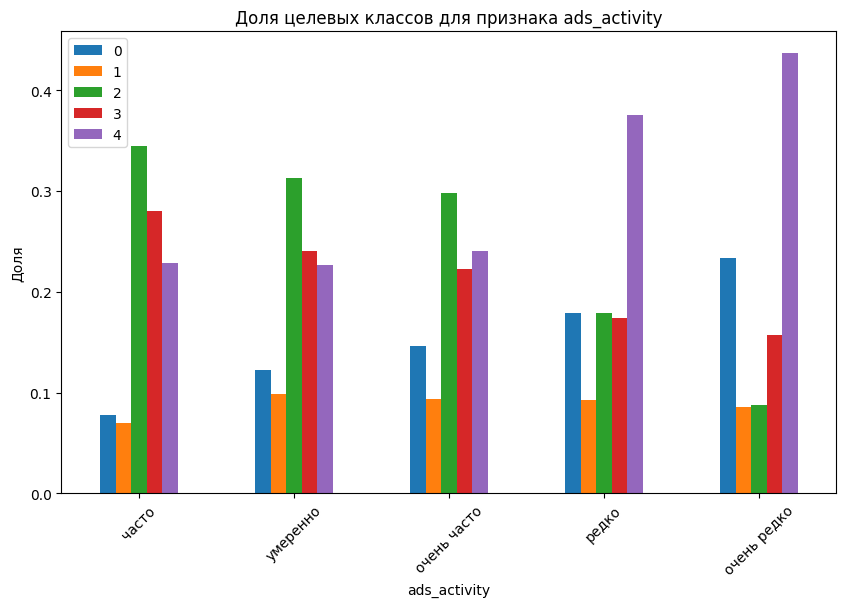

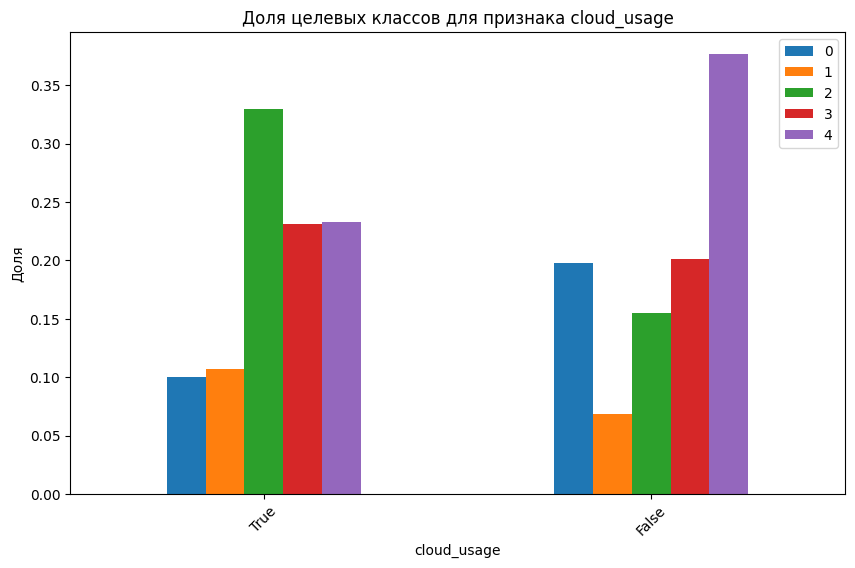

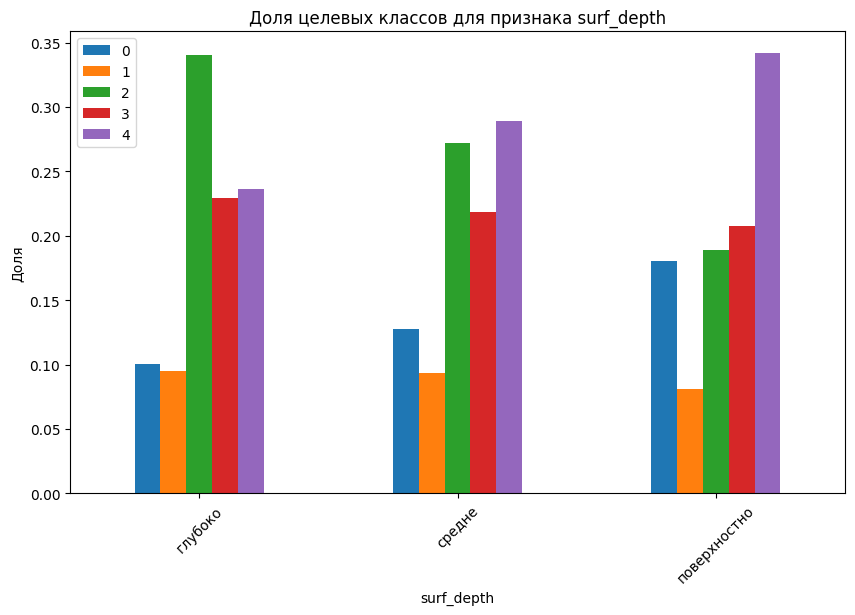

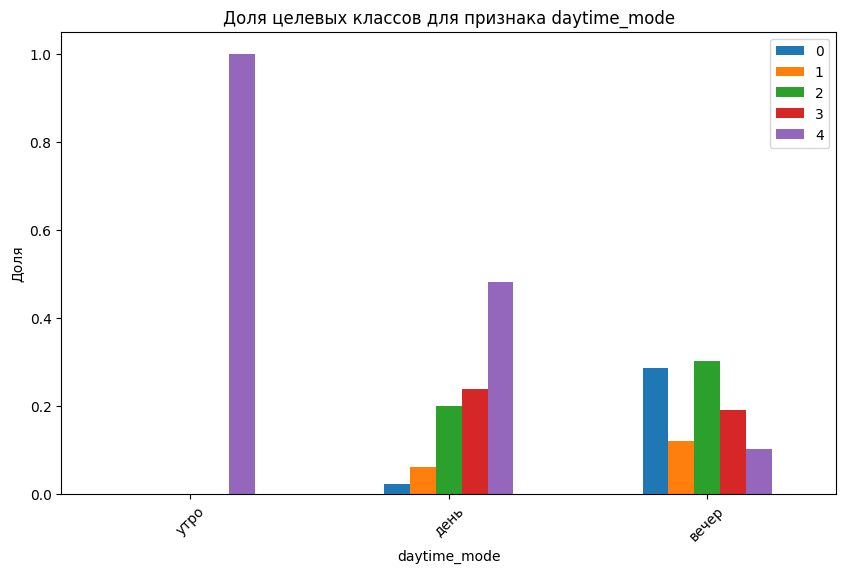

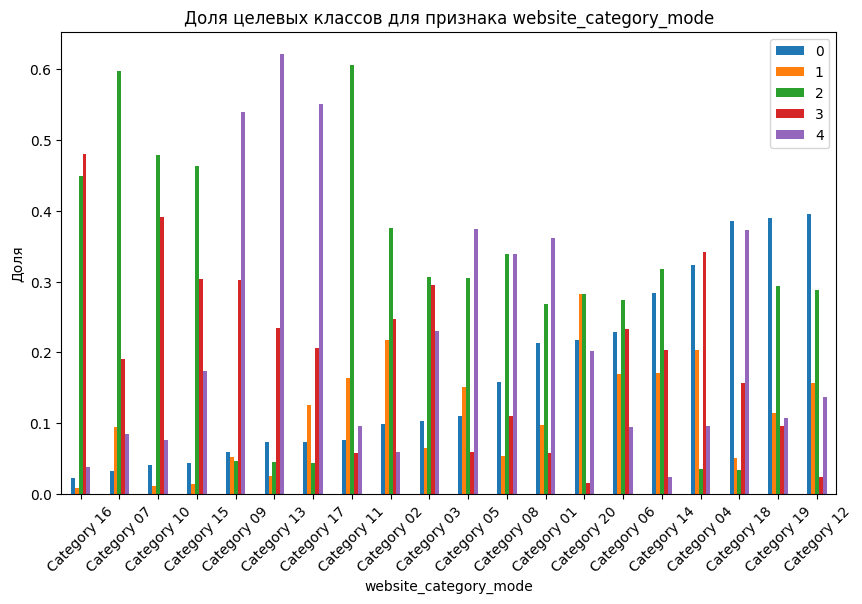

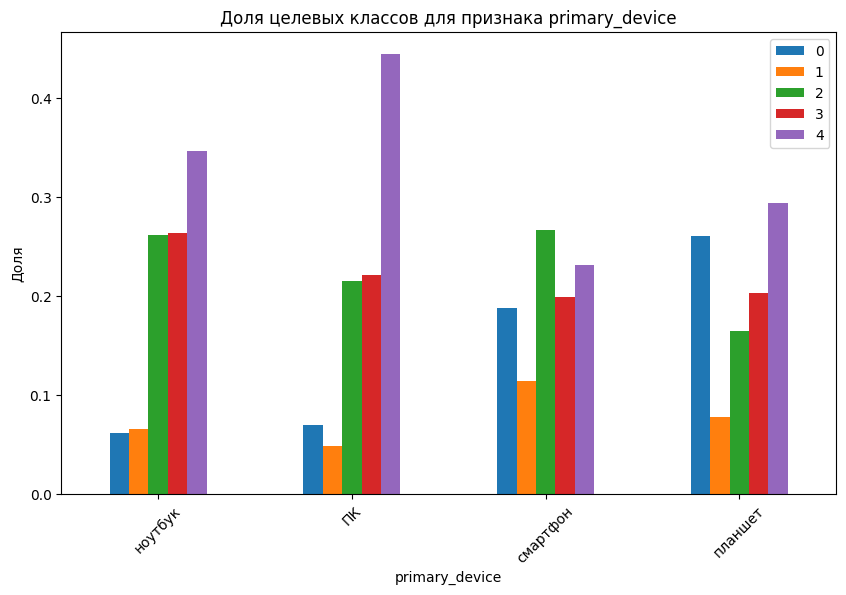

In [98]:
cat_cols_names = cat_cols_names[1:]
for name in cat_cols_names:
    plot_bar_target_class(df=df, target_name='age_category', cat_col=name, sort_target=0)

Анализ:
- доли классов существенно варьируются по данным признакам

Итог:
- признаки потенциально полезны для дальнейшего анализа

### Распределения таргета по числовым признакам

In [99]:
num_cols_names

['age_category', 'session_count', 'mean_sessions_per_day']

<Axes: xlabel='session_count', ylabel='Density'>

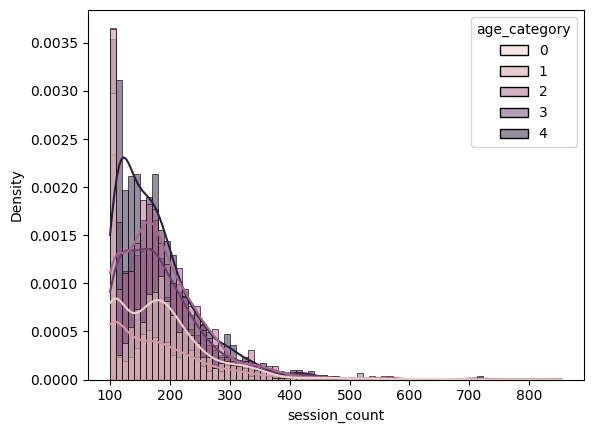

In [100]:
sns.histplot(data=df, x='session_count', hue='age_category', kde=True, stat='density')

<Axes: xlabel='mean_sessions_per_day', ylabel='Density'>

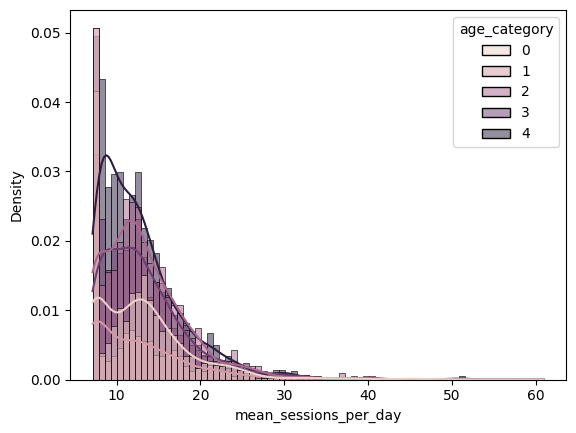

In [101]:
sns.histplot(data=df, x='mean_sessions_per_day', hue='age_category', kde=True, stat='density')

Анализ:
- общий вид распределения признаков смещен. Распределения имеют длинные хвосты.
- распределение среди более молодых смещено вправо: они более активные

Рекомендация:
- применить лог преобразование к признакам, чтобы симметризовать распределения

#### Корреляционный анализ

In [102]:
def get_corr_matrix(
    data: pd.DataFrame, feat_cols: list[str], 
    num_cols: list[str]
):
    """Матрица корреяций"""
    corr_matrix = data[feat_cols].phik_matrix(
        interval_cols=num_cols if len(num_cols) > 0 else None,
        njobs=-1,
    )

    return corr_matrix

def plot_corr_matrix(corr_matrix):
    """Тепловая карта"""
    plt.figure(figsize=(14, 10)) 

    sns.heatmap(data=corr_matrix, annot=True, fmt='.2f', linewidths=0.5, cmap='viridis')

    plt.title('Тепловая карта матрицы корреляций')
    plt.show()

def corr_with_target(corr_matrix, target_col_name):
    """Корреляция с таргетом"""
    return corr_matrix[target_col_name].sort_values(ascending=False)

In [103]:
cat_cols_to_analyse = [name for name in cat_cols_names if len(df[name].unique()) < 100]
corr_matrix = get_corr_matrix(data=df, feat_cols=num_cols_names + cat_cols_names, num_cols=num_cols_names)

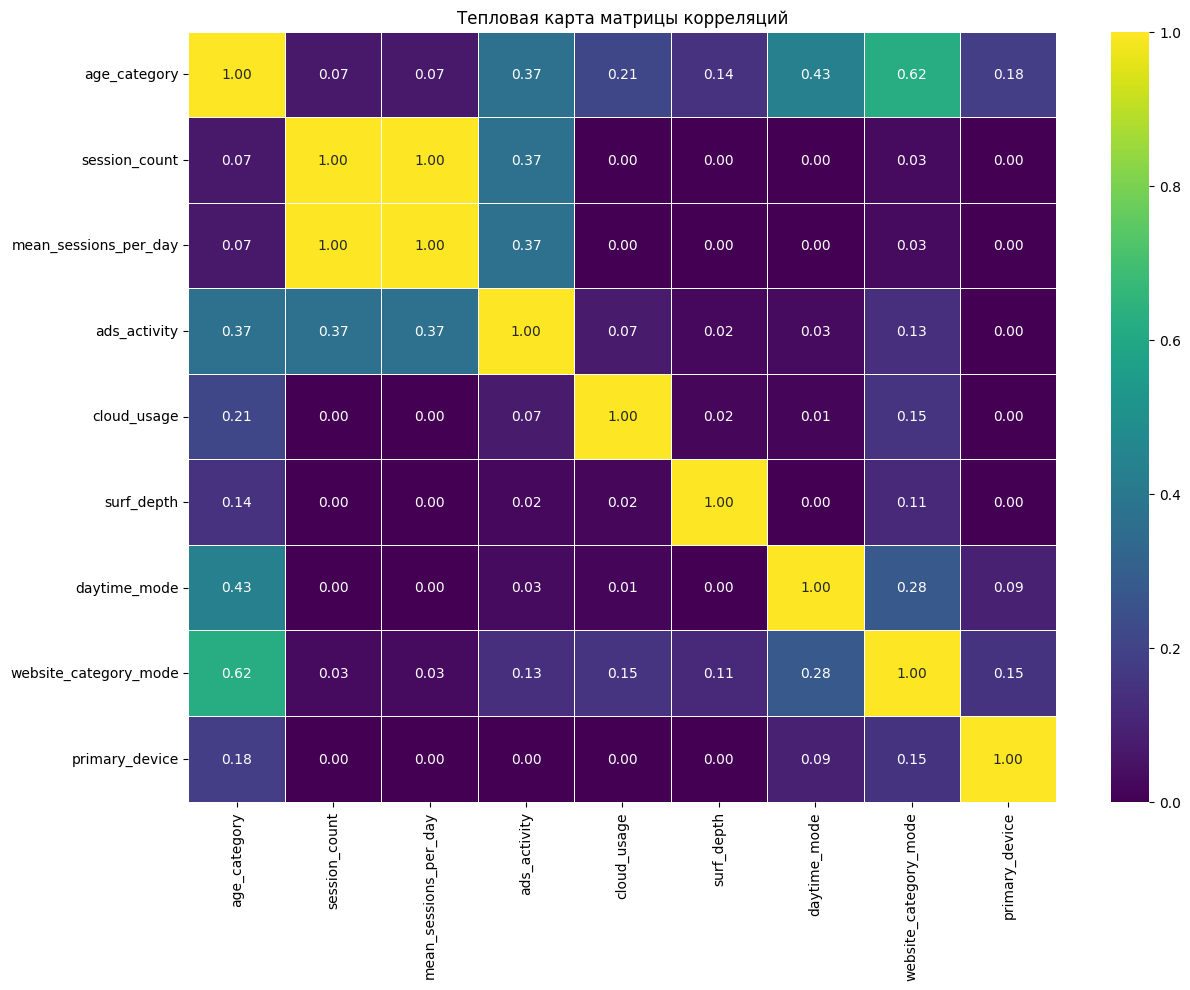

In [104]:
plot_corr_matrix(corr_matrix)

In [105]:
corr_with_target(corr_matrix=corr_matrix, target_col_name='age_category')

age_category             1.000000
website_category_mode    0.624123
daytime_mode             0.431162
ads_activity             0.367874
cloud_usage              0.214420
primary_device           0.183185
surf_depth               0.140736
session_count            0.065577
mean_sessions_per_day    0.065577
Name: age_category, dtype: float64

Анализ:
- наиболее связаны с целевой переменной признаки:  website_category_mode, daytime_mode, ads_activity, cloud_usage, primary_device, surf_depth - корреляция более 0.14
- наименее связанные с таргетом признаки: daytsession_count, mean_sessions_per_day - кандидаты на удаление. Плюс эти признаки высоко коррелируют между собой.

Рекомендация:
- в пайплайн предобработки встроить фильтрацию по низкой корреляции с таргетом + убирать высоко скоррелированные между собой признаки

### Итог

По таблице visits сформированы агрегированные признаки:
- 'session_count', 'mean_sessions_per_day', 'daytime_mode', 'website_category_mode'
- опираясь на корреляционный анализ, можно сделать вывод, что новые признаки 'daytime_mode', 'website_category_mode' скорее всего полезны для модели. Их корреляция с age_category более 0.4

Общий датафрейм:
- данные объединены в общую таблицу по user_id. После объединения:
    - найдены явные дубли в малочисленные дубликаты (около 5%) были удалены
    - имеются пропуски, которые необходимо заменить в пайплайне статистиками распределений 

Категориальные признаки:
- рекомендация по кодированию: OneHot, если кол-во уникальных значений < 10, иначе Target
- ads_activity, surf_depth по смыслу логично преобразовать в дискретный набор последовательных чисел
- date стоит преобразовать в формат datetime
- website_category - стоит перевести в числовой формат: уникальные значения пронумеровать числами

Числовые признаки:
- сформированы признаки 'session_count', 'mean_sessions_per_day' - распределения смещенные, необходимо обрабатывать выбросы. Рекомендуется логарифмировать признаки, чтобы распреления были более симметричными

Целевая переменная:
- классы не сбалансированы, необходимо применять стратификацию при разбиении на test/train

Наиболее перспективные признаки:
- session_count, daytime_mode, website_category_mode, ads_activity - корреляция с age_category более 0.4

Наименее полезные признаки:
- 'user_id' - не несет полезной информации для анализа
- 'session_count', 'mean_sessions_per_day' - низкая корреляция с таргетом, по результатам корреляционного анализа после разделения выборок скорее всего отфильтреются

## 3. Предобработка данных

### Фильтрация неинформативных признаков

In [106]:
df.duplicated(subset='user_id').sum() # все user_id уникальны

np.int64(0)

In [107]:
df = df.drop(columns='user_id')

In [108]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5826 entries, 0 to 6145
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age_category           5826 non-null   int64  
 1   ads_activity           5593 non-null   object 
 2   cloud_usage            5680 non-null   object 
 3   surf_depth             5715 non-null   object 
 4   session_count          5826 non-null   int64  
 5   daytime_mode           5826 non-null   object 
 6   website_category_mode  5826 non-null   object 
 7   mean_sessions_per_day  5826 non-null   float64
 8   primary_device         5669 non-null   object 
dtypes: float64(1), int64(2), object(6)
memory usage: 455.2+ KB


#### Преобразование типов

In [109]:
df['ads_activity'] = df['ads_activity'].replace(
    to_replace={'очень редко': 0, 'редко': 1, 'умеренно': 2, 'часто': 3, 'очень часто': 4}).infer_objects(copy=False)

df['surf_depth'] = df['surf_depth'].replace(
    to_replace={'поверхностно': 0, 'средне': 1, 'глубоко': 2}).infer_objects(copy=False)

categories_str = sorted(df['website_category_mode'].unique().tolist())
categories_num = [i for i in range(1, len(categories_str) + 1)]
website_category_replace_dict = {name_str: num for name_str, num in zip(categories_str, categories_num)}

df['website_category_mode'] = df['website_category_mode'].replace(
    to_replace=website_category_replace_dict).infer_objects(copy=False)


/var/folders/z5/m0jnh3gs29l1r8s11wsrcwyr0000gp/T/ipykernel_79943/1991145929.py:1: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['ads_activity'] = df['ads_activity'].replace(
/var/folders/z5/m0jnh3gs29l1r8s11wsrcwyr0000gp/T/ipykernel_79943/1991145929.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['surf_depth'] = df['surf_depth'].replace(
/var/folders/z5/m0jnh3gs29l1r8s11wsrcwyr0000gp/T/ipykernel_79943/1991145929.py:11: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version.

In [110]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5826 entries, 0 to 6145
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   age_category           5826 non-null   int64  
 1   ads_activity           5593 non-null   float64
 2   cloud_usage            5680 non-null   object 
 3   surf_depth             5715 non-null   float64
 4   session_count          5826 non-null   int64  
 5   daytime_mode           5826 non-null   object 
 6   website_category_mode  5826 non-null   int64  
 7   mean_sessions_per_day  5826 non-null   float64
 8   primary_device         5669 non-null   object 
dtypes: float64(3), int64(3), object(3)
memory usage: 455.2+ KB


In [111]:
NUM_COLS_SPECIAL = ['ads_activity', 'surf_depth', 'website_category_mode', 'cloud_usage']


Итог:
- признаки ads_activity, surf_depth, website_category_mode преобразованы к числовому формату
- стоит учесть, что это дискретные величины при дальнейшем анализе 
- cloud_usage в стоит сперва заменить пропуски на моду, а потом уже преобразовать к int

### Разделение на train/test

In [112]:
X = df.drop(columns=['age_category'])
y = df['age_category']

In [113]:
X_train_full, X_test, y_train_full, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED, stratify=y)


X_val, X_train, y_val, y_train = train_test_split(
    X_train_full, y_train_full, test_size=0.75, random_state=RANDOM_SEED, stratify=y_train_full
)

In [114]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape, X_val.shape, y_val.shape

((3495, 8), (1166, 8), (3495,), (1166,), (1165, 8), (1165,))

### Пайплайн предобработки

In [115]:
class CorrelationFilter(BaseEstimator, TransformerMixin):
    """
    Фильтрация признаков по корреляции:
    1. удаляет признаки с низкой корреляцией с целевой переменной;
    2. из пар сильно скоррелированных признаков оставляет тот,
       который сильнее связан с целевой переменной.
    """

    def __init__(self, low_target_threshold=0.05, high_corr_threshold=0.90):
        self.low_target_threshold = low_target_threshold
        self.high_corr_threshold = high_corr_threshold

    def _to_dataframe(self, X, columns=None, index=None):
        
        if isinstance(X, pd.DataFrame):
            return X.copy()

        if columns is None:
            columns = [f'x{i}' for i in range(X.shape[1])]

        return pd.DataFrame(X, columns=columns, index=index)

    def fit(self, X, y):
        """Отбор признаков по корреляции между собой и с целевой переменной."""

        X_df = self._to_dataframe(X)
        self.feature_names_in_ = np.asarray(X_df.columns, dtype=object)

        y_series = pd.Series(y, index=X_df.index, name='target')
        target_corr = X_df.corrwith(y_series).abs().fillna(0.0)
        self.target_corr_ = target_corr

        self.low_corr_features_ = target_corr[
            target_corr < self.low_target_threshold
        ].index.tolist()

        X_filtered = X_df.drop(columns=self.low_corr_features_, errors='ignore')
        self.high_corr_features_ = []

        if X_filtered.shape[1] > 1:
            feature_corr = X_filtered.corr().abs().fillna(0.0)
            upper_mask = np.triu(np.ones(feature_corr.shape, dtype=bool), k=1)

            high_corr_pairs = (
                feature_corr.where(upper_mask)
                .stack()
                .reset_index()
                .rename(columns={'level_0': 'feature_1', 'level_1': 'feature_2', 0: 'corr'})
                .query('corr > @self.high_corr_threshold')
                .sort_values('corr', ascending=False)
                .reset_index(drop=True)
            )

            dropped = set()
            for _, row in high_corr_pairs.iterrows():
                feature_1 = row['feature_1']
                feature_2 = row['feature_2']

                if feature_1 in dropped or feature_2 in dropped:
                    continue

                corr_1 = target_corr.get(feature_1, 0.0)
                corr_2 = target_corr.get(feature_2, 0.0)

                if corr_1 < corr_2:
                    dropped.add(feature_1)
                else:
                    dropped.add(feature_2)

            self.high_corr_features_ = [col for col in X_filtered.columns if col in dropped]

        cols_to_drop = set(self.low_corr_features_) | set(self.high_corr_features_)
        self.cols_to_drop_ = [col for col in self.feature_names_in_ if col in cols_to_drop]
        return self

    def transform(self, X):
        X_df = self._to_dataframe(X, columns=self.feature_names_in_)
        return X_df.drop(columns=self.cols_to_drop_, errors='ignore')

    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            input_features = self.feature_names_in_
        return np.asarray([col for col in input_features if col not in self.cols_to_drop_], dtype=object)


In [116]:
class CustomPreprocessor(BaseEstimator, TransformerMixin):
    """
    Обёртка над ColumnTransformer, которая:
    - обучает внутренний preprocessor
    - преобразует данные
    - возвращает pd.DataFrame с именами признаков
    """

    def __init__(self, preprocessor):
        self.preprocessor = preprocessor

    def fit(self, X, y=None):
        self.preprocessor_ = clone(self.preprocessor)
        self.preprocessor_.fit(X, y)
        self.feature_names_ = self.preprocessor_.get_feature_names_out()
        return self

    def transform(self, X):
        X_transformed = self.preprocessor_.transform(X)

        if sparse.issparse(X_transformed):
            X_transformed = X_transformed.toarray()

        return pd.DataFrame(
            X_transformed,
            columns=self.feature_names_,
            index=X.index
        )

    def fit_transform(self, X, y=None):
        self.preprocessor_ = clone(self.preprocessor)
        X_transformed = self.preprocessor_.fit_transform(X, y)
        self.feature_names_ = self.preprocessor_.get_feature_names_out()

        if sparse.issparse(X_transformed):
            X_transformed = X_transformed.toarray()

        return pd.DataFrame(
            X_transformed,
            columns=self.feature_names_,
            index=X.index
        )

    def get_feature_names_out(self, input_features=None):
        return np.asarray(self.feature_names_, dtype=object)


In [117]:
def select_cat_one_hot(X):
    cat_cols = X.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    return [name for name in cat_cols if X[name].nunique() < 10]

def select_cat_target(X):
    cat_cols = X.select_dtypes(include=CAT_COLS_TYPES).columns.tolist()
    return [name for name in cat_cols if X[name].nunique() >= 10]

def select_num_continues(X):
    num_cols_continues = X.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()
    return [name for name in num_cols_continues if name not in NUM_COLS_SPECIAL]

def select_num_special(X):
    num_cols = X.select_dtypes(include=NUM_COLS_TYPES).columns.tolist()
    return [name for name in num_cols if name in NUM_COLS_SPECIAL]

In [118]:
def create_preprocessing_pipeline(
    with_filtering: bool = True,
    low_target_threshold=0.05,
    high_corr_threshold=0.90
) -> Pipeline:
    """
    Создание пайплайна предобратботки данных.

    Args:
        with_filtering (bool): Включать ли фильтрацию признаков.
    Returns:
        Pipeline: Пайплайн фильтрации и предобработки данных
    """

    # Пайплайны для разных типов признаков
    cat_one_hot_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'))
    ])

    cat_target_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', TargetEncoder())
    ])

    num_cols_continues_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ])  

    num_special_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler', MinMaxScaler())
    ])

    transformers = [
        ('cat_one_hot', cat_one_hot_pipeline, select_cat_one_hot),
        ('cat_target', cat_target_pipeline, select_cat_target),
        ('num_continues', num_cols_continues_pipeline, select_num_continues),
        ('special', num_special_pipeline, select_num_special),
    ]
    
    preprocessor = ColumnTransformer(
        transformers=transformers,
        remainder='drop'
    )

    result_pipeline = [
        ('prep', CustomPreprocessor(preprocessor))
    ]
    if with_filtering:
        result_pipeline.append(
            ('corr_filter', CorrelationFilter(  # фильтрация по корреляции
                low_target_threshold=low_target_threshold,
                high_corr_threshold=high_corr_threshold
            ))
        )

    return Pipeline(result_pipeline)


## 4. Обучение и оценка базовой модели

В результате ИАД было определено, что среди целевой переменной наблюдается дисбаланс классов. В качестве основного подхода для решения задачи многоклассовой классификации выбираем **One-vs-Rest**, так как он лучше подходит для несбалансированных данных.

In [119]:
def evaluate_model(y_true, y_pred):
    metrics = {
        'accuracy': accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, average='macro'),
        'precision_micro': precision_score(y_true, y_pred, average='micro'),
        'precision_weighted': precision_score(y_true, y_pred, average='weighted'),
        'recall_macro': recall_score(y_true, y_pred, average='macro'),
        'recall_micro': recall_score(y_true, y_pred, average='micro'),
        'recall_weighted': recall_score(y_true, y_pred, average='weighted'),
        'f1_macro': f1_score(y_true, y_pred, average='macro'),
        'f1_micro': f1_score(y_true, y_pred, average='micro'),
        'f1_weighted': f1_score(y_true, y_pred, average='weighted'),
        'confusion_matrix': confusion_matrix(y_true, y_pred)
    }
    return metrics

def get_result_df(model_names: list[str], metric_dicts: list[dict]):
    # Преобразование результатов в датафрейм
    df_results = pd.DataFrame({
        name: {k: v for k, v in metric_dict.items() if k != 'confusion_matrix'} for name, metric_dict in zip(model_names, metric_dicts)
    })
    return df_results

In [120]:
def train_test_result_pipeline(pipeline: Pipeline, X_train, y_train, X_val):
    """Обучение пайплайна и формирование предсказания"""
    # Обучаем на тренировочных данных
    pipeline.fit(X_train, y_train)
    # Делаем предсказания на валидационной выборке
    val_preds = pipeline.predict(X_val)
    return  val_preds

### Базовый пайплайн предобработки данных


In [121]:
base_preprocessor = create_preprocessing_pipeline(with_filtering=False)

### Инициализация базовых моделей

In [ ]:
# Dummy
dummy_model= DummyClassifier(random_state=RANDOM_SEED)
ovr_dummy = OneVsRestClassifier(estimator=dummy_model)

base_pipeline_dummy = Pipeline([
    ('prep', base_preprocessor),
    ('model', ovr_dummy)
])

# Logreg
base_logreg = LogisticRegression(random_state=RANDOM_SEED, class_weight="balanced", max_iter=1000)
ovr_logreg = OneVsRestClassifier(base_logreg)
base_pipeline_ovr_logreg = Pipeline([
    ('prep', base_preprocessor),
    ('model', ovr_logreg)   
])

# SVC
base_svc = SVC(random_state=RANDOM_SEED, kernel="linear")
ovr_svc = OneVsRestClassifier(base_svc)
base_pipeline_ovr_svc = Pipeline([
    ('prep', base_preprocessor),
    ('model', ovr_svc)   
])

base_pipelines = [
    base_pipeline_dummy,
    base_pipeline_ovr_logreg,
    base_pipeline_ovr_svc
]

### Обучение

In [123]:
base_model_results = []

for pipeline in base_pipelines:
    val_pred  = train_test_result_pipeline(pipeline=pipeline, X_train=X_train, y_train=y_train, X_val=X_val)
    result = evaluate_model(y_true=y_val, y_pred=val_pred)
    base_model_results.append(result)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/

### Результаты

### 

In [135]:
base_model_results_df = get_result_df(
    model_names=['DummyOvR', 'BaseLogregOvR', 'BaseSVCOvR'],
    metric_dicts=base_model_results
)
base_model_results_df

,DummyOvR,BaseLogregOvR,BaseSVCOvR
accuracy,0.303004,0.454936,0.416309
precision_macro,0.060601,0.370937,0.295443
precision_micro,0.303004,0.454936,0.416309
precision_weighted,0.091812,0.414213,0.338692
recall_macro,0.200000,0.407377,0.329217
recall_micro,0.303004,0.454936,0.416309
recall_weighted,0.303004,0.454936,0.416309
f1_macro,0.093017,0.364667,0.290984
f1_micro,0.303004,0.454936,0.416309
f1_weighted,0.140923,0.412153,0.352712


#### Анализ:
- предсказания моделей **BaseLogregOvR** и **BaseSVCOvR** существенно выше **Dummy** классификатора по всем метрикам, что свидетельствует об отсутствии явных ошибок в предобработке данных.


## Создание и отбор признаков

In [149]:
preprocessor_filtered = create_preprocessing_pipeline(with_filtering=True, high_corr_threshold=0.9, low_target_threshold=0.01)

### Пайплайны с отбором признаков

In [150]:
# Dummy
dummy_model= DummyClassifier(random_state=RANDOM_SEED)
ovr_dummy = OneVsRestClassifier(estimator=dummy_model)

filtered_pipeline_dummy = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', ovr_dummy)
])

# Logreg
base_logreg = LogisticRegression(random_state=RANDOM_SEED, class_weight="balanced", max_iter=1000)
ovr_logreg = OneVsRestClassifier(base_logreg)
filtered_pipeline_ovr_logreg = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', ovr_logreg)   
])

# SVC
base_svc = SVC(random_state=RANDOM_SEED, kernel="linear")
ovr_svc = OneVsRestClassifier(base_svc)
filtered_pipeline_ovr_svc = Pipeline([
    ('prep', preprocessor_filtered),
    ('model', ovr_svc)   
])

filtered_pipelines = [
    filtered_pipeline_dummy,
    filtered_pipeline_ovr_logreg,
    filtered_pipeline_ovr_svc
]

### Обучение

In [151]:
filtered_model_results = []

for pipeline in filtered_pipelines:
    val_pred  = train_test_result_pipeline(pipeline=pipeline, X_train=X_train, y_train=y_train, X_val=X_val)
    result = evaluate_model(y_true=y_val, y_pred=val_pred)
    filtered_model_results.append(result)

/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/a.plahotniuc/Workspace/practicum_ds/.venv/lib/python3.9/site-packages/

In [152]:
filtered_model_results_df = get_result_df(
    model_names=['dummy_ovr_filtered', 'base_logreg_ovr_filtered', 'base_svc_ovr_filtered'],
    metric_dicts=filtered_model_results
)
filtered_model_results_df

,dummy_ovr_filtered,base_logreg_ovr_filtered,base_svc_ovr_filtered
accuracy,0.303004,0.454077,0.411159
precision_macro,0.060601,0.368915,0.333532
precision_micro,0.303004,0.454077,0.411159
precision_weighted,0.091812,0.412034,0.360225
recall_macro,0.200000,0.406811,0.348520
recall_micro,0.303004,0.454077,0.411159
recall_weighted,0.303004,0.454077,0.411159
f1_macro,0.093017,0.364336,0.319475
f1_micro,0.303004,0.454077,0.411159
f1_weighted,0.140923,0.411692,0.359656


In [153]:
pd.merge(base_model_results_df, filtered_model_results_df, left_index=True, right_index=True)

,DummyOvR,BaseLogregOvR,BaseSVCOvR,dummy_ovr_filtered,base_logreg_ovr_filtered,base_svc_ovr_filtered
accuracy,0.303004,0.454936,0.416309,0.303004,0.454077,0.411159
precision_macro,0.060601,0.370937,0.295443,0.060601,0.368915,0.333532
precision_micro,0.303004,0.454936,0.416309,0.303004,0.454077,0.411159
precision_weighted,0.091812,0.414213,0.338692,0.091812,0.412034,0.360225
recall_macro,0.200000,0.407377,0.329217,0.200000,0.406811,0.348520
recall_micro,0.303004,0.454936,0.416309,0.303004,0.454077,0.411159
recall_weighted,0.303004,0.454936,0.416309,0.303004,0.454077,0.411159
f1_macro,0.093017,0.364667,0.290984,0.093017,0.364336,0.319475
f1_micro,0.303004,0.454936,0.416309,0.303004,0.454077,0.411159
f1_weighted,0.140923,0.412153,0.352712,0.140923,0.411692,0.359656


## Подбор гиперпараметров моделей

## Подготовка артефактов модели для внедрения

## Выводы о результатах работы